# 05 — Final ResNet-50 Multi-label Dynamic GRL

This notebook is the dynamic-scheduling counterpart to notebook 04. It uses the **same fixed patient-level split, seven labels, ImageNet-pretrained ResNet-50 backbone, preprocessing, batch size, optimiser, loss functions, seed set, maximum epoch budget, validation-only threshold protocol, and test evaluation**.

The **only planned methodological difference** from Static GRL is the adversarial-strength schedule:

- **Static GRL (04):** `lambda_adv = 0.1` throughout training.
- **Dynamic GRL (05):** `lambda_adv` follows a DANN-style smooth schedule from 0 towards the same `lambda_max = 0.1`.

The disease checkpoint is selected **only** by validation disease macro AUROC. The sex-head metrics are auxiliary representation diagnostics and are not used for checkpoint selection.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

from r50_multilabel_final_common import (
    MultiLabelAdversarialResNet50,
    base_run_config,
    build_label_fairness_summary,
    build_loaders,
    checkpoint_payload,
    compute_test_metrics_by_group,
    ensure_output_dirs,
    evaluate_adversarial,
    get_device,
    load_fixed_multilabel_data,
    make_disease_criterion,
    save_prediction_archive,
    seed_everything,
    select_per_label_thresholds,
    summarise_overall_fairness,
    train_dynamic_adv_one_epoch,
)

# Final experimental protocol: change values only before beginning a new full experiment.
FINAL_SEEDS = [42, 123, 2026]
BATCH_SIZE = 16
NUM_EPOCHS = 12

# This must equal the fixed static-GRL strength in notebook 04.
LAMBDA_MAX = 0.1
SCHEDULE_GAMMA = 10.0
THRESHOLD_METRIC = "f1"
EXPERIMENT_ID = "r50_dynamic_grl_final_multiseed_v1"

# Bootstrap is intentionally optional because it is computationally expensive.
# Enable it only after all three seed-level outputs have completed successfully.
RUN_PATIENT_CLUSTER_BOOTSTRAP = False
N_BOOTSTRAP = 1000
BOOTSTRAP_RANDOM_SEED = 202606

ensure_output_dirs()
Path("figures").mkdir(exist_ok=True)
device = get_device()

print("Device:", device)
print("Experiment ID:", EXPERIMENT_ID)
print("Seeds:", FINAL_SEEDS)
print("Dynamic GRL lambda_max:", LAMBDA_MAX)
print("Dynamic GRL schedule gamma:", SCHEDULE_GAMMA)


Device: mps
Experiment ID: r50_dynamic_grl_final_multiseed_v1
Seeds: [42, 123, 2026]
Dynamic GRL lambda_max: 0.1
Dynamic GRL schedule gamma: 10.0


## Load the frozen patient-level split and shared multi-label protocol


In [2]:
train_df, val_df, test_df, selected_labels, label_columns, audit_config = load_fixed_multilabel_data()

# The final protocol must not recreate, rebalance, or alter the existing split.
train_patients = set(train_df["Patient ID"].astype(str))
val_patients = set(val_df["Patient ID"].astype(str))
test_patients = set(test_df["Patient ID"].astype(str))
assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

criterion_for_weights, pos_weight_table, pos_weight_values = make_disease_criterion(
    train_df, label_columns, device
)
del criterion_for_weights  # A fresh disease criterion is created for every seed-level run.
sex_criterion = torch.nn.BCEWithLogitsLoss()

print("Selected labels:", selected_labels)
print("Split sizes:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print("Batch size:", BATCH_SIZE)
display(pos_weight_table)


Selected labels: ['Infiltration', 'Effusion', 'Atelectasis', 'Nodule', 'Mass', 'Pneumothorax', 'Consolidation']
Split sizes: {'train': 78873, 'validation': 10953, 'test': 22294}
Batch size: 16


,label,train_positive,train_negative,pos_weight
0,Infiltration,13868,65005,4.687410
1,Effusion,9533,69340,7.273681
2,Atelectasis,8262,70611,8.546478
3,Nodule,4415,74458,16.864779
4,Mass,4199,74674,17.783758
5,Pneumothorax,3841,75032,19.534496
6,Consolidation,3280,75593,23.046646


## Seed-level dynamic-GRL training, validation-only thresholding, and final test evaluation

The model architecture and total loss are identical to Static GRL. The GRL applies the current `lambda_adv` in the backward pass; therefore the total loss remains:

`disease_loss + sex_loss`

The sex loss is **not** multiplied by `lambda_adv` a second time.


In [3]:
def run_dynamic_grl_seed(seed: int):
    """Train one independent dynamic-GRL run and save all seed-level artefacts."""
    seed_everything(seed)
    run_tag = f"r50_dynamic_grl_seed{seed}"
    output_prefix = Path("results") / run_tag
    best_model_path = Path("checkpoints") / f"{run_tag}_best.pt"

    train_loader, val_loader, test_loader = build_loaders(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        label_columns=label_columns,
        seed=seed,
        batch_size=BATCH_SIZE,
    )

    model = MultiLabelAdversarialResNet50(n_labels=len(selected_labels)).to(device)
    feature_dim = model.feature_dim
    disease_criterion, _, _ = make_disease_criterion(train_df, label_columns, device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    total_steps = NUM_EPOCHS * len(train_loader)
    run_config = base_run_config(
        seed=seed,
        selected_labels=selected_labels,
        feature_dim=feature_dim,
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        pos_weight_values=pos_weight_values,
        checkpoint_path=best_model_path,
    )
    run_config.update(
        {
            "experiment_id": EXPERIMENT_ID,
            "model_variant": "r50_dynamic_grl",
            "adversarial_training": True,
            "adversarial_schedule": "DANN-style logistic schedule",
            "lambda_max": float(LAMBDA_MAX),
            "schedule_gamma": float(SCHEDULE_GAMMA),
            "schedule_initial_lambda": 0.0,
            "schedule_total_training_steps": int(total_steps),
            "static_comparison_lambda_adv": float(LAMBDA_MAX),
            "sex_head": "Linear(feature_dim, 1)",
            "sex_loss": "BCEWithLogitsLoss",
            "total_loss": "disease_loss + sex_loss; lambda_adv applied only by GRL",
            "threshold_metric": f"validation_{THRESHOLD_METRIC}",
            "audit_config_source": "results/multilabel_selected_labels.json",
            "core_selection_rules": audit_config.get("core_selection_rules", {}),
        }
    )

    print(f"\n{'=' * 76}\nStarting {run_tag}")
    print("Disease head:", model.disease_head)
    print("Sex head:", model.sex_head)
    print("feature_dim obtained from base.fc.in_features:", feature_dim)
    print(f"Schedule: lambda_max={LAMBDA_MAX}, gamma={SCHEDULE_GAMMA}, total_steps={total_steps}")

    history = []
    schedule_rows = []
    best_val_macro_auroc = -np.inf
    best_epoch = None
    global_step = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_results = train_dynamic_adv_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            disease_criterion=disease_criterion,
            sex_criterion=sex_criterion,
            device=device,
            epoch=epoch,
            global_step=global_step,
            total_steps=total_steps,
            lambda_max=LAMBDA_MAX,
            gamma=SCHEDULE_GAMMA,
        )
        global_step = train_results["global_step"]
        for row in train_results["schedule_rows"]:
            row["seed"] = seed
            row["model_variant"] = "r50_dynamic_grl"
        schedule_rows.extend(train_results["schedule_rows"])

        val_results = evaluate_adversarial(
            model=model,
            loader=val_loader,
            disease_criterion=disease_criterion,
            sex_criterion=sex_criterion,
            device=device,
            labels=selected_labels,
        )

        history_row = {
            "seed": seed,
            "epoch": epoch,
            "lambda_start": train_results["lambda_start"],
            "lambda_end": train_results["lambda_end"],
            "lambda_mean": train_results["lambda_mean"],
            "train_loss": train_results["loss"],
            "train_disease_loss": train_results["disease_loss"],
            "train_sex_loss": train_results["sex_loss"],
            "val_loss": val_results["loss"],
            "val_disease_loss": val_results["disease_loss"],
            "val_sex_loss": val_results["sex_loss"],
            "val_macro_auroc": val_results["disease_macro_auroc"],
            "val_macro_auprc": val_results["disease_macro_auprc"],
            "val_sex_auroc": val_results["sex_auroc"],
            "val_sex_accuracy": val_results["sex_accuracy"],
        }
        history.append(history_row)

        print(
            f"Seed {seed} | Epoch {epoch}/{NUM_EPOCHS} | "
            f"lambda={train_results['lambda_start']:.4f}->{train_results['lambda_end']:.4f} "
            f"(mean={train_results['lambda_mean']:.4f}) | "
            f"train disease loss={train_results['disease_loss']:.4f} | "
            f"val disease macro AUROC={val_results['disease_macro_auroc']:.4f} | "
            f"val disease macro AUPRC={val_results['disease_macro_auprc']:.4f} | "
            f"val sex AUROC={val_results['sex_auroc']:.4f} | "
            f"val sex accuracy={val_results['sex_accuracy']:.4f}"
        )

        if val_results["disease_macro_auroc"] > best_val_macro_auroc:
            best_val_macro_auroc = float(val_results["disease_macro_auroc"])
            best_epoch = epoch
            torch.save(
                checkpoint_payload(model, epoch, best_val_macro_auroc, run_config),
                best_model_path,
            )
            print("  Saved checkpoint selected by validation disease macro AUROC.")

    if best_epoch is None:
        raise RuntimeError(f"No checkpoint was saved for seed {seed}.")

    history_df = pd.DataFrame(history)
    schedule_df = pd.DataFrame(schedule_rows)

    # Load only the validation-selected checkpoint before selecting thresholds or evaluating test performance.
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device).eval()

    val_final = evaluate_adversarial(
        model=model,
        loader=val_loader,
        disease_criterion=disease_criterion,
        sex_criterion=sex_criterion,
        device=device,
        labels=selected_labels,
    )
    test_final = evaluate_adversarial(
        model=model,
        loader=test_loader,
        disease_criterion=disease_criterion,
        sex_criterion=sex_criterion,
        device=device,
        labels=selected_labels,
    )

    assert len(val_final["probs"]) == len(val_df), "Threshold selection must use the complete validation set."
    assert len(test_final["probs"]) == len(test_df), "Test prediction count mismatch."
    assert len(schedule_df) == total_steps, "Dynamic schedule must record every training step."

    thresholds_df = select_per_label_thresholds(
        probs=val_final["probs"],
        targets=val_final["targets"],
        labels=selected_labels,
        metric=THRESHOLD_METRIC,
    )
    test_overall_by_label, test_subgroup_metrics = compute_test_metrics_by_group(
        probs=test_final["probs"],
        targets=test_final["targets"],
        sexes=test_final["sexes"],
        labels=selected_labels,
        thresholds_df=thresholds_df,
    )
    label_fairness_summary = build_label_fairness_summary(
        overall_metrics=test_overall_by_label,
        subgroup_metrics=test_subgroup_metrics,
        model_name="r50_dynamic_grl",
    )
    fairness_means = summarise_overall_fairness(label_fairness_summary)

    # Seed metadata is included in every exported table to support later multi-seed aggregation.
    for frame in [test_overall_by_label, test_subgroup_metrics, label_fairness_summary]:
        frame.insert(0, "seed", seed)
        frame.insert(0, "model_variant", "r50_dynamic_grl")

    overall_result = pd.DataFrame(
        [
            {
                "model_variant": "r50_dynamic_grl",
                "model": "r50_dynamic_grl",
                "seed": seed,
                "n_labels": len(selected_labels),
                "selected_labels": "|".join(selected_labels),
                "lambda_max": float(LAMBDA_MAX),
                "schedule_gamma": float(SCHEDULE_GAMMA),
                "best_epoch": int(best_epoch),
                "best_val_macro_auroc": float(best_val_macro_auroc),
                "test_macro_auroc": float(test_final["disease_macro_auroc"]),
                "test_macro_auprc": float(test_final["disease_macro_auprc"]),
                "test_sex_auroc": float(test_final["sex_auroc"]),
                "test_sex_accuracy": float(test_final["sex_accuracy"]),
                **fairness_means,
            }
        ]
    )

    # Persist every item needed for reproducibility, multi-seed summaries, schedule plots, and bootstrap CIs.
    pos_weight_table.to_csv(f"{output_prefix}_pos_weights.csv", index=False)
    history_df.to_csv(f"{output_prefix}_training_history.csv", index=False)
    schedule_df.to_csv(f"{output_prefix}_lambda_schedule_stepwise.csv", index=False)
    thresholds_df.to_csv(f"{output_prefix}_thresholds.csv", index=False)
    test_overall_by_label.to_csv(f"{output_prefix}_test_label_metrics.csv", index=False)
    test_subgroup_metrics.to_csv(f"{output_prefix}_subgroup_metrics.csv", index=False)
    label_fairness_summary.to_csv(f"{output_prefix}_label_fairness_summary.csv", index=False)
    overall_result.to_csv(f"{output_prefix}_overall_results.csv", index=False)

    run_config.update(
        {
            "best_epoch": int(best_epoch),
            "best_validation_macro_auroc": float(best_val_macro_auroc),
            "final_validation_macro_auroc": float(val_final["disease_macro_auroc"]),
            "final_validation_macro_auprc": float(val_final["disease_macro_auprc"]),
            "final_validation_sex_auroc": float(val_final["sex_auroc"]),
            "final_validation_sex_accuracy": float(val_final["sex_accuracy"]),
            "test_macro_auroc": float(test_final["disease_macro_auroc"]),
            "test_macro_auprc": float(test_final["disease_macro_auprc"]),
            "test_sex_auroc": float(test_final["sex_auroc"]),
            "test_sex_accuracy": float(test_final["sex_accuracy"]),
            "lambda_final_step": float(schedule_df["lambda_adv"].iloc[-1]),
        }
    )
    with open(f"{output_prefix}_run_config.json", "w", encoding="utf-8") as f:
        json.dump(run_config, f, indent=2)

    save_prediction_archive(
        f"{output_prefix}_validation_predictions.npz",
        val_final,
        selected_labels,
        adversarial=True,
    )
    save_prediction_archive(
        f"{output_prefix}_test_predictions.npz",
        test_final,
        selected_labels,
        adversarial=True,
    )

    print(f"\nCompleted {run_tag}")
    print("Best epoch:", best_epoch)
    print("Test macro AUROC:", test_final["disease_macro_auroc"])
    print("Test macro AUPRC:", test_final["disease_macro_auprc"])
    print("Test sex-head AUROC:", test_final["sex_auroc"])
    print("Test sex-head accuracy:", test_final["sex_accuracy"])
    display(overall_result)

    return {
        "seed": seed,
        "run_tag": run_tag,
        "output_prefix": str(output_prefix),
        "overall_result": overall_result,
        "test_label_metrics": test_overall_by_label,
        "subgroup_metrics": test_subgroup_metrics,
        "label_fairness_summary": label_fairness_summary,
        "schedule": schedule_df,
    }


## Run the three independent seed-level dynamic-GRL experiments


In [4]:
seed_runs = [run_dynamic_grl_seed(seed) for seed in FINAL_SEEDS]



Starting r50_dynamic_grl_seed42
Disease head: Linear(in_features=2048, out_features=7, bias=True)
Sex head: Linear(in_features=2048, out_features=1, bias=True)
feature_dim obtained from base.fc.in_features: 2048
Schedule: lambda_max=0.1, gamma=10.0, total_steps=59160
Seed 42 | Epoch 1/12 | lambda=0.0000->0.0394 (mean=0.0203) | train disease loss=1.0419 | val disease macro AUROC=0.7884 | val disease macro AUPRC=0.2685 | val sex AUROC=0.5123 | val sex accuracy=0.5212
  Saved checkpoint selected by validation disease macro AUROC.
Seed 42 | Epoch 2/12 | lambda=0.0394->0.0682 (mean=0.0549) | train disease loss=0.9537 | val disease macro AUROC=0.8015 | val disease macro AUPRC=0.2911 | val sex AUROC=0.5155 | val sex accuracy=0.5379
  Saved checkpoint selected by validation disease macro AUROC.
Seed 42 | Epoch 3/12 | lambda=0.0682->0.0848 (mean=0.0774) | train disease loss=0.9025 | val disease macro AUROC=0.8045 | val disease macro AUPRC=0.2937 | val sex AUROC=0.5896 | val sex accuracy=0.5722

,model_variant,model,seed,n_labels,selected_labels,lambda_max,schedule_gamma,best_epoch,best_val_macro_auroc,test_macro_auroc,test_macro_auprc,test_sex_auroc,test_sex_accuracy,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_grl,r50_dynamic_grl,42,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,10.0,4,0.808821,0.809404,0.308938,0.548012,0.576343,0.034334,0.009641,0.034334,0.445068,0.01323



Starting r50_dynamic_grl_seed123
Disease head: Linear(in_features=2048, out_features=7, bias=True)
Sex head: Linear(in_features=2048, out_features=1, bias=True)
feature_dim obtained from base.fc.in_features: 2048
Schedule: lambda_max=0.1, gamma=10.0, total_steps=59160
Seed 123 | Epoch 1/12 | lambda=0.0000->0.0394 (mean=0.0203) | train disease loss=1.0429 | val disease macro AUROC=0.7953 | val disease macro AUPRC=0.2826 | val sex AUROC=0.5388 | val sex accuracy=0.5727
  Saved checkpoint selected by validation disease macro AUROC.
Seed 123 | Epoch 2/12 | lambda=0.0394->0.0682 (mean=0.0549) | train disease loss=0.9548 | val disease macro AUROC=0.7891 | val disease macro AUPRC=0.2838 | val sex AUROC=0.5634 | val sex accuracy=0.5601
Seed 123 | Epoch 3/12 | lambda=0.0682->0.0848 (mean=0.0774) | train disease loss=0.9021 | val disease macro AUROC=0.8087 | val disease macro AUPRC=0.3007 | val sex AUROC=0.5240 | val sex accuracy=0.5443
  Saved checkpoint selected by validation disease macro AU

,model_variant,model,seed,n_labels,selected_labels,lambda_max,schedule_gamma,best_epoch,best_val_macro_auroc,test_macro_auroc,test_macro_auprc,test_sex_auroc,test_sex_accuracy,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_grl,r50_dynamic_grl,123,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,10.0,3,0.808732,0.806299,0.302735,0.563315,0.563156,0.059146,0.020766,0.059445,0.425127,0.011826



Starting r50_dynamic_grl_seed2026
Disease head: Linear(in_features=2048, out_features=7, bias=True)
Sex head: Linear(in_features=2048, out_features=1, bias=True)
feature_dim obtained from base.fc.in_features: 2048
Schedule: lambda_max=0.1, gamma=10.0, total_steps=59160
Seed 2026 | Epoch 1/12 | lambda=0.0000->0.0394 (mean=0.0203) | train disease loss=1.0461 | val disease macro AUROC=0.7859 | val disease macro AUPRC=0.2652 | val sex AUROC=0.5397 | val sex accuracy=0.5587
  Saved checkpoint selected by validation disease macro AUROC.
Seed 2026 | Epoch 2/12 | lambda=0.0394->0.0682 (mean=0.0549) | train disease loss=0.9586 | val disease macro AUROC=0.7980 | val disease macro AUPRC=0.2882 | val sex AUROC=0.5375 | val sex accuracy=0.5710
  Saved checkpoint selected by validation disease macro AUROC.
Seed 2026 | Epoch 3/12 | lambda=0.0682->0.0848 (mean=0.0774) | train disease loss=0.9053 | val disease macro AUROC=0.8092 | val disease macro AUPRC=0.2961 | val sex AUROC=0.5134 | val sex accurac

,model_variant,model,seed,n_labels,selected_labels,lambda_max,schedule_gamma,best_epoch,best_val_macro_auroc,test_macro_auroc,test_macro_auprc,test_sex_auroc,test_sex_accuracy,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_grl,r50_dynamic_grl,2026,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,10.0,3,0.809186,0.807284,0.303415,0.556243,0.58204,0.042369,0.013537,0.042399,0.445934,0.014557


## Save and plot the Dynamic GRL schedule


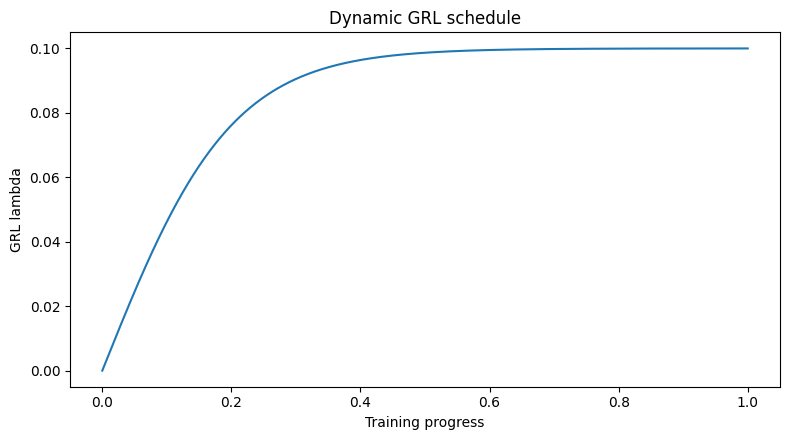

,global_step,progress,lambda_adv_mean,lambda_adv_std
0,0,0.000000,0.000000,0.0
1,1,0.000017,0.000008,0.0
2,2,0.000034,0.000017,0.0
3,3,0.000051,0.000025,0.0
4,4,0.000068,0.000034,0.0


,global_step,progress,lambda_adv_mean,lambda_adv_std
59155,59155,0.999932,0.099991,0.0
59156,59156,0.999949,0.099991,0.0
59157,59157,0.999966,0.099991,0.0
59158,59158,0.999983,0.099991,0.0
59159,59159,1.000000,0.099991,0.0


In [5]:
schedule_all = pd.concat([run["schedule"] for run in seed_runs], ignore_index=True)
schedule_summary = (
    schedule_all.groupby(["global_step", "progress"], as_index=False)
    .agg(
        lambda_adv_mean=("lambda_adv", "mean"),
        lambda_adv_std=("lambda_adv", "std"),
    )
)

schedule_all.to_csv(
    "results/r50_dynamic_grl_multiseed_lambda_schedule_stepwise.csv",
    index=False,
)
schedule_summary.to_csv(
    "results/r50_dynamic_grl_multiseed_lambda_schedule_mean_std.csv",
    index=False,
)

plt.figure(figsize=(8, 4.5))
plt.plot(schedule_summary["progress"], schedule_summary["lambda_adv_mean"])
plt.xlabel("Training progress")
plt.ylabel("GRL lambda")
plt.title("Dynamic GRL schedule")
plt.tight_layout()
plt.savefig("figures/r50_dynamic_grl_lambda_schedule.png", dpi=300)
plt.show()

display(schedule_summary.head())
display(schedule_summary.tail())


## Aggregate multi-seed results


In [6]:
def aggregate_mean_std(df: pd.DataFrame, group_columns, metric_columns) -> pd.DataFrame:
    """Aggregate completed seed-level results into mean and sample standard deviation."""
    metric_columns = [c for c in metric_columns if c in df.columns]
    numeric = df[list(group_columns) + metric_columns].copy()
    for metric in metric_columns:
        numeric[metric] = pd.to_numeric(numeric[metric], errors="coerce")
    grouped = numeric.groupby(list(group_columns), dropna=False)[metric_columns]
    mean_df = grouped.mean().add_suffix("_mean")
    std_df = grouped.std(ddof=1).add_suffix("_std")
    n_df = grouped.count().add_suffix("_n_seeds")
    return pd.concat([mean_df, std_df, n_df], axis=1).reset_index()

overall_all = pd.concat([run["overall_result"] for run in seed_runs], ignore_index=True)
label_metrics_all = pd.concat([run["test_label_metrics"] for run in seed_runs], ignore_index=True)
subgroup_metrics_all = pd.concat([run["subgroup_metrics"] for run in seed_runs], ignore_index=True)
label_fairness_all = pd.concat([run["label_fairness_summary"] for run in seed_runs], ignore_index=True)

overall_summary = aggregate_mean_std(
    overall_all,
    group_columns=["model_variant", "model", "lambda_max", "schedule_gamma"],
    metric_columns=[
        "best_epoch",
        "best_val_macro_auroc",
        "test_macro_auroc",
        "test_macro_auprc",
        "test_sex_auroc",
        "test_sex_accuracy",
        "mean_FNR_gap",
        "mean_FPR_gap",
        "mean_Equalized_Odds_gap",
        "mean_Worst_group_Recall",
        "mean_AUROC_gap",
    ],
)
per_label_summary = aggregate_mean_std(
    label_metrics_all,
    group_columns=["model_variant", "label"],
    metric_columns=[
        "support", "positive_support", "negative_support",
        "AUROC", "AUPRC", "TPR", "Recall", "FNR", "TNR", "Specificity", "FPR",
    ],
)
subgroup_summary = aggregate_mean_std(
    subgroup_metrics_all,
    group_columns=["model_variant", "group", "label"],
    metric_columns=[
        "support", "positive_support", "negative_support",
        "AUROC", "AUPRC", "TPR", "Recall", "FNR", "TNR", "Specificity", "FPR",
    ],
)
fairness_summary = aggregate_mean_std(
    label_fairness_all,
    group_columns=["model_variant", "label"],
    metric_columns=[
        "test_AUROC", "test_AUPRC",
        "female_AUROC", "male_AUROC",
        "female_FNR", "male_FNR",
        "female_FPR", "male_FPR",
        "FNR_gap", "FPR_gap", "Equalized_Odds_gap",
        "AUROC_gap", "AUPRC_gap",
        "Worst_group_Recall", "Worst_group_AUROC",
    ],
)

summary_prefix = Path("results") / "r50_dynamic_grl_multiseed"
overall_all.to_csv(f"{summary_prefix}_seed_level_overall_results.csv", index=False)
label_metrics_all.to_csv(f"{summary_prefix}_seed_level_test_label_metrics.csv", index=False)
subgroup_metrics_all.to_csv(f"{summary_prefix}_seed_level_subgroup_metrics.csv", index=False)
label_fairness_all.to_csv(f"{summary_prefix}_seed_level_label_fairness.csv", index=False)
overall_summary.to_csv(f"{summary_prefix}_overall_mean_std.csv", index=False)
per_label_summary.to_csv(f"{summary_prefix}_per_label_mean_std.csv", index=False)
subgroup_summary.to_csv(f"{summary_prefix}_subgroup_mean_std.csv", index=False)
fairness_summary.to_csv(f"{summary_prefix}_label_fairness_mean_std.csv", index=False)

display(overall_all)
display(overall_summary)


,model_variant,model,seed,n_labels,selected_labels,lambda_max,schedule_gamma,best_epoch,best_val_macro_auroc,test_macro_auroc,test_macro_auprc,test_sex_auroc,test_sex_accuracy,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_grl,r50_dynamic_grl,42,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,10.0,4,0.808821,0.809404,0.308938,0.548012,0.576343,0.034334,0.009641,0.034334,0.445068,0.013230
1,r50_dynamic_grl,r50_dynamic_grl,123,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,10.0,3,0.808732,0.806299,0.302735,0.563315,0.563156,0.059146,0.020766,0.059445,0.425127,0.011826
2,r50_dynamic_grl,r50_dynamic_grl,2026,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,10.0,3,0.809186,0.807284,0.303415,0.556243,0.582040,0.042369,0.013537,0.042399,0.445934,0.014557


,model_variant,model,lambda_max,schedule_gamma,best_epoch_mean,best_val_macro_auroc_mean,test_macro_auroc_mean,test_macro_auprc_mean,test_sex_auroc_mean,test_sex_accuracy_mean,...,best_val_macro_auroc_n_seeds,test_macro_auroc_n_seeds,test_macro_auprc_n_seeds,test_sex_auroc_n_seeds,test_sex_accuracy_n_seeds,mean_FNR_gap_n_seeds,mean_FPR_gap_n_seeds,mean_Equalized_Odds_gap_n_seeds,mean_Worst_group_Recall_n_seeds,mean_AUROC_gap_n_seeds
0,r50_dynamic_grl,r50_dynamic_grl,0.1,10.0,3.333333,0.808913,0.807662,0.305029,0.555857,0.573846,...,3,3,3,3,3,3,3,3,3,3


## Optional 95% sex-stratified patient-cluster bootstrap confidence intervals

This bootstrap samples **Patient IDs**, not individual images, with replacement within Female and Male groups. Every sampled patient contributes all of their test images. The same resampled patient clusters are applied to all completed seeds, while each seed retains its validation-derived frozen thresholds.

Set `RUN_PATIENT_CLUSTER_BOOTSTRAP = True` only after all three dynamic-GRL seed runs have completed.


In [7]:
def _load_dynamic_seed_archive(seed_run):
    output_prefix = Path(seed_run["output_prefix"])
    archive = np.load(f"{output_prefix}_test_predictions.npz", allow_pickle=False)
    return {
        "seed": seed_run["seed"],
        "probs": archive["probs"],
        "targets": archive["targets"],
        "sexes": archive["sexes"].astype(int),
        "patient_ids": archive["patient_ids"].astype(str),
        "image_indices": archive["image_indices"].astype(str),
        "labels": archive["labels"].astype(str).tolist(),
        "sex_probs": archive["sex_probs"],
        "thresholds_df": pd.read_csv(f"{output_prefix}_thresholds.csv"),
    }

def _sample_patient_clusters_by_sex(sexes, patient_ids, rng):
    sexes = np.asarray(sexes).astype(int)
    patient_ids = np.asarray(patient_ids).astype(str)
    patient_to_image_indices = {}
    patient_to_sex = {}

    for idx, (patient_id, sex) in enumerate(zip(patient_ids, sexes)):
        patient_to_image_indices.setdefault(patient_id, []).append(idx)
        if patient_id in patient_to_sex and patient_to_sex[patient_id] != sex:
            raise ValueError(f"Inconsistent sex encoding for Patient ID {patient_id}.")
        patient_to_sex[patient_id] = sex

    sampled_chunks = []
    for sex_value in (0, 1):
        ids = np.asarray(
            [patient_id for patient_id, sex in patient_to_sex.items() if sex == sex_value],
            dtype=str,
        )
        if len(ids) == 0:
            raise ValueError("Both Female and Male patients are required for subgroup bootstrap.")
        sampled_ids = rng.choice(ids, size=len(ids), replace=True)
        sampled_chunks.extend(
            np.asarray(patient_to_image_indices[patient_id], dtype=int)
            for patient_id in sampled_ids
        )
    return np.concatenate(sampled_chunks)

def _metrics_from_bootstrap_sample(archive, indices):
    probs = archive["probs"][indices]
    targets = archive["targets"][indices]
    sexes = archive["sexes"][indices]
    labels = archive["labels"]

    overall_metrics, subgroup_metrics = compute_test_metrics_by_group(
        probs=probs,
        targets=targets,
        sexes=sexes,
        labels=labels,
        thresholds_df=archive["thresholds_df"],
    )
    label_fairness = build_label_fairness_summary(
        overall_metrics=overall_metrics,
        subgroup_metrics=subgroup_metrics,
        model_name="bootstrap",
    )
    fairness = summarise_overall_fairness(label_fairness)

    sex_probs = archive["sex_probs"][indices]
    return {
        "test_macro_auroc": float(np.nanmean(overall_metrics["AUROC"])),
        "test_macro_auprc": float(np.nanmean(overall_metrics["AUPRC"])),
        "test_sex_auroc": (
            float(roc_auc_score(sexes, sex_probs))
            if np.unique(sexes).size == 2 else np.nan
        ),
        "test_sex_accuracy": float(accuracy_score(sexes, (sex_probs >= 0.5).astype(int))),
        **fairness,
    }

if RUN_PATIENT_CLUSTER_BOOTSTRAP:
    bootstrap_archives = [_load_dynamic_seed_archive(seed_run) for seed_run in seed_runs]
    reference = bootstrap_archives[0]

    # All seed archives must use the same immutable test split in the same order.
    for archive in bootstrap_archives[1:]:
        assert archive["labels"] == reference["labels"]
        assert np.array_equal(archive["targets"], reference["targets"])
        assert np.array_equal(archive["sexes"], reference["sexes"])
        assert np.array_equal(archive["patient_ids"], reference["patient_ids"])
        assert np.array_equal(archive["image_indices"], reference["image_indices"])

    ci_metrics = [
        "test_macro_auroc",
        "test_macro_auprc",
        "mean_FNR_gap",
        "mean_FPR_gap",
        "mean_Equalized_Odds_gap",
        "mean_Worst_group_Recall",
        "mean_AUROC_gap",
        "test_sex_auroc",
        "test_sex_accuracy",
    ]
    rng = np.random.default_rng(BOOTSTRAP_RANDOM_SEED)
    bootstrap_rows = []

    for iteration in range(N_BOOTSTRAP):
        sampled_indices = _sample_patient_clusters_by_sex(
            sexes=reference["sexes"],
            patient_ids=reference["patient_ids"],
            rng=rng,
        )
        seed_rows = [
            _metrics_from_bootstrap_sample(archive, sampled_indices)
            for archive in bootstrap_archives
        ]
        mean_metrics = pd.DataFrame(seed_rows)[ci_metrics].mean(axis=0)
        bootstrap_rows.append(
            {
                "bootstrap_iteration": iteration,
                "n_images_in_resample": int(len(sampled_indices)),
                "n_seeds_aggregated": int(len(bootstrap_archives)),
                **mean_metrics.to_dict(),
            }
        )

    bootstrap_distribution = pd.DataFrame(bootstrap_rows)
    point_estimates = overall_all[ci_metrics].mean(axis=0)
    bootstrap_ci = pd.DataFrame(
        [
            {
                "model_variant": "r50_dynamic_grl",
                "metric": metric,
                "point_estimate_mean_across_seeds": float(point_estimates[metric]),
                "ci_level": 0.95,
                "ci_lower": float(np.nanpercentile(bootstrap_distribution[metric], 2.5)),
                "ci_upper": float(np.nanpercentile(bootstrap_distribution[metric], 97.5)),
                "n_bootstrap": int(N_BOOTSTRAP),
                "n_seeds_aggregated": int(len(bootstrap_archives)),
                "resampling_unit": "Patient ID cluster, stratified by sex",
                "threshold_policy": "Seed-specific validation-derived per-label thresholds fixed in all bootstrap replicates",
            }
            for metric in ci_metrics
        ]
    )

    bootstrap_distribution.to_csv(
        "results/r50_dynamic_grl_patient_cluster_bootstrap_distribution.csv",
        index=False,
    )
    bootstrap_ci.to_csv(
        "results/r50_dynamic_grl_patient_cluster_bootstrap_95ci.csv",
        index=False,
    )
    display(bootstrap_ci)
else:
    print(
        "Bootstrap code is ready but disabled. After all three seed runs finish, set "
        "RUN_PATIENT_CLUSTER_BOOTSTRAP = True and rerun this cell."
    )


Bootstrap code is ready but disabled. After all three seed runs finish, set RUN_PATIENT_CLUSTER_BOOTSTRAP = True and rerun this cell.


## Interpretation boundary

Sex-head AUROC or accuracy near chance is only auxiliary evidence that the trained adversary finds sex harder to recover from the shared representation. It is not itself a fairness metric and must not be interpreted as proof that sex-related information has been removed or that fairness has improved. The primary conclusions must be based on diagnostic performance, Female/Male subgroup metrics, fairness gaps, multi-seed variability, and confidence intervals.
